In [ ]:
!pip install ultralytics --upgrade --quiet

import os
import zipfile

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 110.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 81.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 58.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 109.9 MB/s eta 0:00:00


In [ ]:
# downloading VOC 2012 dataset
!wget http://host.robots.ox.ac.uk/pascal/VOC/voc2012/VOCtrainval_11-May-2012.tar

# extract
!tar -xf VOCtrainval_11-May-2012.tar


--2025-05-23 13:43:43--  http://host.robots.ox.ac.uk/pascal/VOC/voc2012/VOCtrainval_11-May-2012.tar
Resolving host.robots.ox.ac.uk (host.robots.ox.ac.uk)... 129.67.94.152
Connecting to host.robots.ox.ac.uk (host.robots.ox.ac.uk)|129.67.94.152|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1999639040 (1.9G) [application/x-tar]
Saving to: ‘VOCtrainval_11-May-2012.tar’

VOCtrainval_11-May- 100%[===================>]   1.86G  27.3MB/s    in 88s     

2025-05-23 13:45:11 (21.7 MB/s) - ‘VOCtrainval_11-May-2012.tar’ saved [1999639040/1999639040]



In [ ]:
import xml.etree.ElementTree as ET
from tqdm import tqdm

# VOC class
VOC_CLASSES = [
    "aeroplane", "bicycle", "bird", "boat", "bottle",
    "bus", "car", "cat", "chair", "cow", "diningtable",
    "dog", "horse", "motorbike", "person", "pottedplant",
    "sheep", "sofa", "train", "tvmonitor"
]

CLASS_TO_ID = {cls: i for i, cls in enumerate(VOC_CLASSES)}

def convert_voc_to_yolo(voc_ann_path, output_dir):
    os.makedirs(output_dir, exist_ok=True)

    for xml_file in tqdm(os.listdir(voc_ann_path)):
        if not xml_file.endswith(".xml"):
            continue

        xml_path = os.path.join(voc_ann_path, xml_file)
        tree = ET.parse(xml_path)
        root = tree.getroot()

        image_w = int(root.find("size/width").text)
        image_h = int(root.find("size/height").text)

        lines = []
        for obj in root.findall("object"):
            cls_name = obj.find("name").text
            if cls_name not in CLASS_TO_ID:
                continue

            cls_id = CLASS_TO_ID[cls_name]
            bbox = obj.find("bndbox")
            xmin = float(bbox.find("xmin").text)
            ymin = float(bbox.find("ymin").text)
            xmax = float(bbox.find("xmax").text)
            ymax = float(bbox.find("ymax").text)


            # YOLO format: cx, cy, w, h (normalized)
            cx = ((xmin + xmax) / 2) / image_w
            cy = ((ymin + ymax) / 2) / image_h
            w = (xmax - xmin) / image_w
            h = (ymax - ymin) / image_h

            lines.append(f"{cls_id} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}")

        # Save .txt
        txt_filename = xml_file.replace(".xml", ".txt")
        with open(os.path.join(output_dir, txt_filename), "w") as f:
            f.write("\n".join(lines))

voc_ann_path = "VOCdevkit/VOC2012/Annotations"
yolo_labels_output_dir = "VOCdevkit/VOC2012/labels"
convert_voc_to_yolo(voc_ann_path, yolo_labels_output_dir)


100%|██████████| 17125/17125 [00:04<00:00, 3853.78it/s]


In [ ]:
from shutil import copyfile

os.makedirs("datasets/VOC/images/train", exist_ok=True)
os.makedirs("datasets/VOC/images/val", exist_ok=True)
os.makedirs("datasets/VOC/labels/train", exist_ok=True)
os.makedirs("datasets/VOC/labels/val", exist_ok=True)

# train/val
with open("VOCdevkit/VOC2012/ImageSets/Main/train.txt") as f:
    train_ids = [line.strip() for line in f.readlines()]

with open("VOCdevkit/VOC2012/ImageSets/Main/val.txt") as f:
    val_ids = [line.strip() for line in f.readlines()]

for image_id in tqdm(train_ids):
    img_src = f"VOCdevkit/VOC2012/JPEGImages/{image_id}.jpg"
    lbl_src = f"VOCdevkit/VOC2012/labels/{image_id}.txt"

    copyfile(img_src, f"datasets/VOC/images/train/{image_id}.jpg")
    copyfile(lbl_src, f"datasets/VOC/labels/train/{image_id}.txt")

for image_id in tqdm(val_ids):
    img_src = f"VOCdevkit/VOC2012/JPEGImages/{image_id}.jpg"
    lbl_src = f"VOCdevkit/VOC2012/labels/{image_id}.txt"

    copyfile(img_src, f"datasets/VOC/images/val/{image_id}.jpg")
    copyfile(lbl_src, f"datasets/VOC/labels/val/{image_id}.txt")


100%|██████████| 5823/5823 [00:04<00:00, 1381.04it/s]


In [ ]:
yaml_content = """
path: datasets/VOC
train: images/train
val: images/val
nc: 20
names: [
  'aeroplane', 'bicycle', 'bird', 'boat', 'bottle',
  'bus', 'car', 'cat', 'chair', 'cow',
  'diningtable', 'dog', 'horse', 'motorbike', 'person',
  'pottedplant', 'sheep', 'sofa', 'train', 'tvmonitor'
]
"""

with open("VOC.yaml", "w") as f:
    f.write(yaml_content.strip())


In [ ]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
import os

train_path = "datasets/VOC/images/train"
val_path = "datasets/VOC/images/val"

train_files = {os.path.splitext(f)[0] for f in os.listdir(train_path) if f.endswith((".jpg", ".png"))}
val_files = {os.path.splitext(f)[0] for f in os.listdir(val_path) if f.endswith((".jpg", ".png"))}

duplicates = train_files.intersection(val_files)

if duplicates:
    print(f"❌ same images in train և val sets. count՝ {len(duplicates)}")
    print("Examples:", list(duplicates)[:5])
else:
    print("✅ there are not duplicates in train and val sets")

✅ there are not duplicates in train and val sets


In [ ]:
model = YOLO("yolov8s.pt")

# train/fine-tune Pascal VOC dataset
results = model.train(
    data="VOC.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    name="yolov8s_voc",
    workers=2,
    patience=20,
    save=True,
    val=True,
    device=0,
    flipud=0.5,
    fliplr=0.5,
    mixup=0.5,
    mosaic= 1,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    lr0=0.01,
    iou=0.20 ,
    label_smoothing=0.1,
    copy_paste=0.05,
    momentum= 0.937

)


WARNING ⚠️ 'label_smoothing' is deprecated and will be removed in in the future.
Ultralytics 8.3.143 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.05, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=VOC.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.2, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.5, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1, multi_scale=False, name=yolov8s_voc3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, 

train: Scanning /content/datasets/VOC/labels/train.cache... 5717 images, 0 backgrounds, 0 corrupt: 100%|██████████| 5717/5717 [00:00<?, ?it/s]

albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


val: Fast image access ✅ (ping: 1.2±2.7 ms, read: 470.1±160.7 MB/s, size: 99.9 KB)


val: Scanning /content/datasets/VOC/labels/val.cache... 5823 images, 0 backgrounds, 0 corrupt: 100%|██████████| 5823/5823 [00:00<?, ?it/s]


...

      21/50      6.55G      1.201      1.643       1.47         42        640: 100%|██████████| 358/358 [02:30<00:00,  2.38it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 182/182 [00:54<00:00,  3.33it/s]

                   all       5823      15787      0.734      0.624       0.67      0.461
EarlyStopping: Training stopped early as no improvement observed in last 20 epochs. Best results observed at epoch 1, best model saved as best.pt.
To update EarlyStopping(patience=20) pass a new patience value, i.e. `patience=300` or use `patience=0` to disable EarlyStopping.



21 epochs completed in 1.207 hours.
Optimizer stripped from runs/detect/yolov8s_voc3/weights/last.pt, 22.5MB
Optimizer stripped from runs/detect/yolov8s_voc3/weights/best.pt, 22.5MB

Validating runs/detect/yolov8s_voc3/weights/best.pt...
Ultralytics 8.3.143 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 11,133,324 parameters, 0 gradients, 28.5 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 182/182 [01:03<00:00,  2.86it/s]


                   all       5823      15787      0.727      0.639      0.676       0.47
             aeroplane        348        484      0.953      0.627      0.752      0.541
               bicycle        290        380      0.801      0.734      0.777      0.553
                  bird        374        629      0.746      0.611      0.667      0.444
                  boat        252        491      0.555      0.467       0.45      0.242
                bottle        369        733      0.716      0.487      0.569      0.382
                   bus        211        320      0.862      0.745      0.796      0.661
                   car        608       1173       0.79      0.684      0.748       0.53
                   cat        544        618      0.679      0.788       0.75       0.53
                 chair        642       1449      0.696      0.445       0.53      0.362
                   cow        154        347      0.734      0.478      0.605      0.407
           diningtabl

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = 'results.csv'
df = pd.read_csv(file_path)

df.columns = df.columns.str.strip()

epochs = df['epoch']
train_box = df['train/box_loss']
val_box = df['val/box_loss']
train_cls = df['train/cls_loss']
val_cls = df['val/cls_loss']
map50 = df['metrics/mAP50(B)']
map5095 = df['metrics/mAP50-95(B)']
precision = df['metrics/precision(B)']
recall = df['metrics/recall(B)']

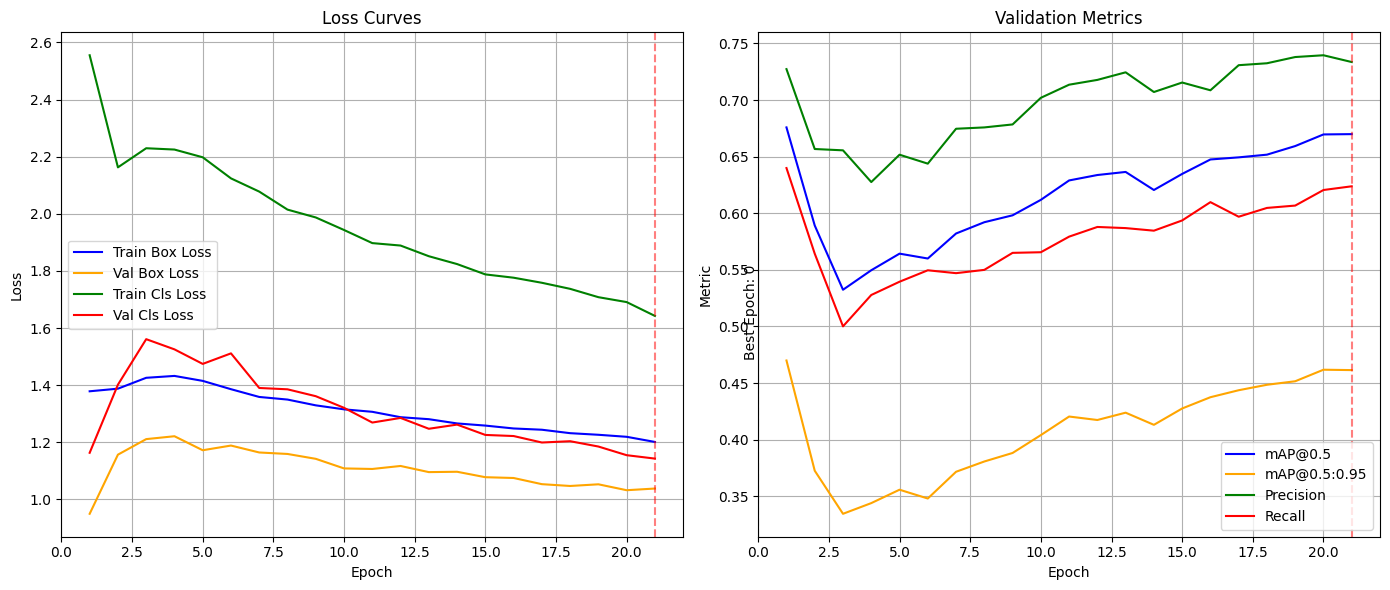

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.plot(epochs, train_box, label='Train Box Loss', color='blue')
ax1.plot(epochs, val_box, label='Val Box Loss', color='orange')
ax1.plot(epochs, train_cls, label='Train Cls Loss', color='green')
ax1.plot(epochs, val_cls, label='Val Cls Loss', color='red')
ax1.set_title('Loss Curves')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(epochs, map50, label='mAP@0.5', color='blue')
ax2.plot(epochs, map5095, label='mAP@0.5:0.95', color='orange')
ax2.plot(epochs, precision, label='Precision', color='green')
ax2.plot(epochs, recall, label='Recall', color='red')
ax2.set_title('Validation Metrics')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Metric')
ax2.legend()
ax2.grid(True)

best_epoch = df['metrics/mAP50-95(B)'].idxmax()
best_map = df.loc[best_epoch, 'metrics/mAP50-95(B)']
ax2.axvline(best_epoch, color='gray', linestyle='--', alpha=0.6)
ax2.text(best_epoch, best_map, f'Best Epoch: {best_epoch}', rotation=90, va='bottom', ha='right', fontsize=10)

last_epoch = df['epoch'].iloc[-1]
ax1.axvline(last_epoch, color='red', linestyle='--', alpha=0.5, label='Early Stopping')
ax2.axvline(last_epoch, color='red', linestyle='--', alpha=0.5, label='Early Stopping')

plt.tight_layout()
plt.show()

In [4]:
# Best epoch data
best_epoch = df['metrics/mAP50-95(B)'].idxmax()
best_row = df.loc[best_epoch]

# Last epoch data
last_epoch = df['epoch'].iloc[-1]
last_row = df[df['epoch'] == last_epoch].iloc[0]

# Print
print(f"\n📌 Best Results (Epoch {best_epoch}):")
print(f"  mAP@0.5: {best_row['metrics/mAP50(B)']:.4f}")
print(f"  mAP@0.5:0.95: {best_row['metrics/mAP50-95(B)']:.4f}")
print(f"  Precision: {best_row['metrics/precision(B)']:.4f}")
print(f"  Recall: {best_row['metrics/recall(B)']:.4f}")

print(f"\n📌 Last Epoch Results (Epoch {last_epoch}):")
print(f"  mAP@0.5: {last_row['metrics/mAP50(B)']:.4f}")
print(f"  mAP@0.5:0.95: {last_row['metrics/mAP50-95(B)']:.4f}")
print(f"  Precision: {last_row['metrics/precision(B)']:.4f}")
print(f"  Recall: {last_row['metrics/recall(B)']:.4f}")



📌 Best Results (Epoch 0):
  mAP@0.5: 0.6758
  mAP@0.5:0.95: 0.4700
  Precision: 0.7273
  Recall: 0.6399

📌 Last Epoch Results (Epoch 21):
  mAP@0.5: 0.6699
  mAP@0.5:0.95: 0.4615
  Precision: 0.7336
  Recall: 0.6238
